# Bibliotecas

In [1]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

# Imports

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 12.10 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/Mercado-Artificial-Fiis


In [3]:
import sys

if "msm" in sys.modules:
    del sys.modules["msm"]


caminho = "/content/Mercado-Artificial-Fiis/notebooks/funcoes"
if caminho not in sys.path:
    sys.path.append(caminho)


import msm

# Bootstrap da janela 500 dias

In [4]:
bootstraps_500 = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/bootstraps_500.csv')

In [5]:
momentos_bootstrap_500 = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_500.csv')

In [6]:
bootstraps_500

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0.002040,0.004117,0.004800,0.003410,-0.000486,-0.000613,-0.001324,-0.007642,-0.008026,-0.003180,...,-0.000030,0.002185,-0.000703,-0.000511,0.001790,-0.003919,0.003730,-0.001486,0.001366,0.002461
1,-0.000022,-0.001024,0.001766,-0.005621,-0.003147,-0.008949,-0.003210,0.003974,0.002568,0.002270,...,0.004938,0.010264,0.002058,0.001486,-0.003827,0.002973,0.001914,0.000202,0.005959,0.006455
2,0.005810,-0.002105,-0.002061,-0.002915,0.003142,-0.001710,-0.001977,0.000014,-0.002224,-0.002024,...,0.001235,0.003714,0.007399,-0.001031,0.001677,0.004238,0.002029,0.004262,-0.003038,0.000151
3,0.001137,-0.000832,-0.001286,-0.000239,-0.000250,0.002354,-0.001503,-0.000577,-0.000996,0.001045,...,-0.006353,-0.000500,-0.001975,0.000534,0.003935,-0.000968,-0.000093,0.000333,-0.002435,0.006768
4,-0.003010,-0.001472,-0.007200,0.011521,-0.001669,0.001986,-0.000109,-0.003969,-0.001888,-0.000334,...,-0.002385,0.001238,0.001008,0.000740,-0.001774,-0.001184,-0.000282,0.001295,0.002930,-0.005311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.003416,-0.000936,-0.003816,-0.002358,-0.001183,-0.005668,0.000757,0.001156,-0.000328,-0.000403,...,0.000043,0.000120,0.001658,0.001698,-0.000105,0.004241,0.005632,0.004338,-0.000117,0.001754
996,-0.004602,0.000311,0.003023,-0.000578,-0.002051,0.000531,-0.001122,0.001122,-0.002076,0.001539,...,-0.002013,-0.001368,-0.000370,0.000394,-0.000639,-0.000955,0.001516,0.002970,0.005142,0.005755
997,-0.001946,-0.003470,-0.004851,0.001200,-0.004908,-0.006927,-0.006551,-0.000350,-0.001753,0.008713,...,-0.002035,0.002291,0.001944,0.000702,-0.000600,-0.000808,0.003100,-0.001828,-0.001200,-0.001695
998,0.001156,-0.000328,-0.000403,-0.002817,0.000455,-0.000379,-0.002807,0.003468,-0.001080,-0.001266,...,-0.006557,0.001858,0.002852,-0.000150,0.000297,0.000960,-0.001191,0.000788,-0.010769,-0.000452


In [7]:
momentos_bootstrap_500

,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.000141,0.000011,0.666245,9.369070,0.100422,0.040643,0.009899,-0.006169,0.151660,0.214680
1,0.000399,0.000012,1.008534,9.101307,0.102057,-0.066555,-0.050478,-0.124395,0.379003,0.207572
2,0.000045,0.000010,-0.076848,6.461567,0.019966,-0.073364,-0.030344,0.025610,0.162999,0.036368
3,-0.000124,0.000020,0.751546,9.421992,0.117835,-0.053933,-0.026230,0.061686,0.454738,0.242761
4,-0.000220,0.000016,0.615142,10.042503,0.108040,0.139802,-0.033636,-0.009115,0.516478,0.201094
...,...,...,...,...,...,...,...,...,...,...
995,-0.000264,0.000014,-0.640608,6.170653,-0.020584,-0.031439,-0.044978,0.040167,0.338306,0.157199
996,-0.000085,0.000011,-0.603628,8.816381,0.078251,0.052669,-0.145757,0.068977,0.555057,0.408623
997,0.000241,0.000011,-0.760707,9.645327,0.125860,-0.037561,-0.051501,0.010615,0.115966,0.201113
998,0.000147,0.000011,-0.079759,8.478551,0.122388,0.075095,-0.010118,0.060319,0.258597,0.003081


## Bootstrap do Power Law

In [8]:
df_power = msm.extrair_powerlaw_bootstrap(
    bootstraps_500=bootstraps_500.values,
    historico_inicial=None,  # coloque None se não quiser concatenar
    max_lag=40,
    b_max=3.0
)

print("Réplicas válidas:", len(df_power), "de", len(bootstraps_500))
df_power.head()

Réplicas válidas: 948 de 1000


,replica,b,r2
0,0,0.881020,0.436281
1,1,2.099494,0.528621
2,2,0.927275,0.631771
3,3,1.183750,0.712309
4,4,2.568910,0.497548


In [9]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde
except ImportError:
    gaussian_kde = None


def plot_histograma(
    dados,
    titulo="Título",
    xlabel="Eixo x",
    ylabel="Densidade",
    grade=True,
    bins=30,
    kde=True,
    mostrar_mediana=True,
    mostrar_ic=True,
    alpha=0.55,
    figsize=(8, 4.8),
    xlim=None
):
    # transforma em array numpy 1D
    dados = np.asarray(dados, dtype=float).ravel()

    # mantém apenas valores finitos
    dados = dados[np.isfinite(dados)]

    # verifica se sobrou dado
    if len(dados) == 0:
        raise ValueError("Não há dados numéricos válidos para plotar.")

    # estatísticas
    med = np.median(dados)
    ci_low = np.percentile(dados, 2.5)
    ci_high = np.percentile(dados, 97.5)

    # figura
    plt.figure(figsize=figsize)

    # histograma
    plt.hist(
        dados,
        bins=bins,
        density=True,
        alpha=alpha,
        edgecolor="black"
    )

    # KDE opcional
    if kde and gaussian_kde is not None and len(dados) > 1:
        xs = np.linspace(np.min(dados), np.max(dados), 300)
        ys = gaussian_kde(dados)(xs)
        plt.plot(xs, ys, linewidth=2, label="Densidade (KDE)")

    # linhas verticais
    if mostrar_mediana:
        plt.axvline(
            med,
            linestyle="--",
            linewidth=2,
            label=f"Mediana = {med:.3f}"
        )

    if mostrar_ic:
        plt.axvline(
            ci_low,
            linestyle=":",
            linewidth=2,
            label=f"IC inf = {ci_low:.3f}"
        )
        plt.axvline(
            ci_high,
            linestyle=":",
            linewidth=2,
            label=f"IC sup = {ci_high:.3f}"
        )

    # títulos e eixos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # limite do eixo x
    if xlim is not None:
        plt.xlim(*xlim)

    # grade
    if grade:
        plt.grid(True, alpha=0.25)

    plt.legend()
    plt.tight_layout()
    plt.show()

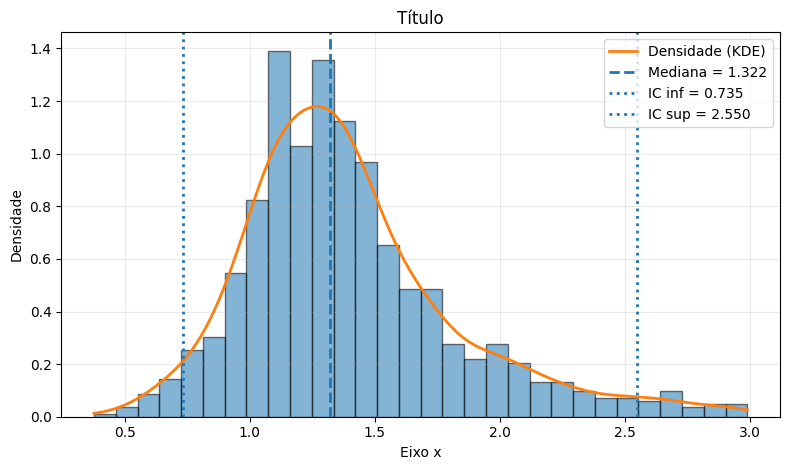

In [10]:
plot_histograma(df_power['b'])

In [11]:
def resumo_serie_df(serie, nome="Série", alpha=0.05):
    """
    Cria um DataFrame com média, desvio padrão, IC_inf e IC_sup de uma série.

    Parâmetros
    ----------
    serie : array-like
        Série de dados.
    nome : str
        Nome da série no DataFrame.
    alpha : float
        Nível de significância. alpha=0.05 gera IC de 95%.

    Retorna
    -------
    pd.DataFrame
    """
    x = np.asarray(serie, dtype=float).ravel()
    x = x[np.isfinite(x)]

    if x.size == 0:
        raise ValueError("A série não possui valores numéricos válidos.")

    media = np.mean(x)
    dp = np.std(x, ddof=1) if x.size > 1 else np.nan
    ic_inf = np.percentile(x, 100 * (alpha / 2))
    ic_sup = np.percentile(x, 100 * (1 - alpha / 2))

    return pd.DataFrame([{
        "Série": nome,
        "Média": media,
        "Desvio padrão": dp,
        "IC_inf": ic_inf,
        "IC_sup": ic_sup
    }])

In [12]:
resumo_serie_df(df_power['b'], nome= 'coeficiente b')

,Série,Média,Desvio padrão,IC_inf,IC_sup
0,coeficiente b,1.397919,0.42791,0.734625,2.549529


## Gaussianidade Agregacional

In [13]:
from scipy.stats import kurtosis
import numpy as np

gaussian_boot = []
escalas = [1, 5, 21]

for j in range(1000):  # 1000 séries bootstrap
    ret = np.array(bootstraps_500.values[j])
    curtoses = []

    for lag in escalas:
        n_blocos = len(ret) // lag
        agregados = np.array([
            np.sum(ret[i*lag:(i+1)*lag]) for i in range(n_blocos)
        ])
        k = kurtosis(agregados, bias=True, fisher=False)
        curtoses.append(k)

    # Curtose decrescente => evidência de gaussianidade agregacional
    is_gaussian = (curtoses[0] > curtoses[1]) and (curtoses[1] >= curtoses[2])
    gaussian_boot.append(is_gaussian)

# Proporção de séries com comportamento gaussianamente agregacional
prop_gaussian = np.mean(gaussian_boot)
print(f"✅ Proporção de gaussianidade agregacional no bootstrap: {prop_gaussian:.2%}")




✅ Proporção de gaussianidade agregacional no bootstrap: 70.40%


## Gaussianidade Condicional

In [14]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.3 MB/s eta 0:00:00


In [15]:
from arch import arch_model

escalas = [1, 5, 21]
gaussian_boot_garch = []

for j in range(1000):  # para cada série bootstrap

    # 1. Série bootstrap
    ret = np.array(bootstraps_500.values[j])

    # 2. Ajuste do modelo GARCH(1,1)
    garch_model = arch_model(100 * ret, vol='GARCH', p=1, q=1, dist='gaussian')
    garch_fit   = garch_model.fit(update_freq=0, disp='off')

    # 3. Resíduos padronizados
    std_resid = np.array(garch_fit.resid / garch_fit.conditional_volatility)

    # 4. Curtoses agregadas
    curtoses = []
    for lag in escalas:
        n_blocos = len(std_resid) // lag

        agregados = np.array([
            np.sum(std_resid[i*lag:(i+1)*lag])
            for i in range(n_blocos)
        ])

        k = kurtosis(agregados, bias=True, fisher=False)
        curtoses.append(k)

    # 5. Curtose estritamente decrescente?
    is_dec = (curtoses[0] > curtoses[1]) and (curtoses[1] > curtoses[2])

    # 6. Armazena o resultado
    gaussian_boot_garch.append(is_dec)

# Proporção final de curtose decrescente
prop_gaussian_boot_garch = np.mean(gaussian_boot_garch)

print(f"Proporção de curtose decrescente nos resíduos GARCH (bootstrap): {prop_gaussian_boot_garch:.2%}")


Proporção de curtose decrescente nos resíduos GARCH (bootstrap): 77.60%


# Simulações

In [16]:
df_500 = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_500_dias.csv')

## Gaussianidade Agregacional

In [31]:
from scipy.stats import kurtosis
import numpy as np

gaussian_sim = []
escalas = [1, 5, 21]

for j in range(350):
    ret = np.array(df_500[df_500["simulacao"] == j]['log_return'].tail(500))
    curtoses = []

    for lag in escalas:
        n_blocos = len(ret) // lag
        agregados = np.array([
            np.sum(ret[i*lag:(i+1)*lag]) for i in range(n_blocos)
        ])
        k = kurtosis(agregados, bias=True, fisher=False)
        curtoses.append(k)

    # Curtose decrescente => evidência de gaussianidade agregacional
    is_gaussian = (curtoses[0] > curtoses[1]) and (curtoses[1] >= curtoses[2])
    gaussian_sim.append(is_gaussian)

# Proporção de séries com comportamento gaussianamente agregacional
prop_gaussian = np.mean(gaussian_sim)
print(f"✅ Proporção de gaussianidade agregacional da simulação: {prop_gaussian:.2%}")

✅ Proporção de gaussianidade agregacional da simulação: 80.00%


## Gaussianidade Condicional

In [19]:
from arch import arch_model
from scipy.stats import kurtosis
import numpy as np

escalas = [1, 5, 21]
gaussian_sim_garch = []
count_valid = 0   # quantas séries realmente foram usadas

for j in range(350):

    # 1. Extrair série simulada
    serie = df_500[df_500["simulacao"] == j+1]['log_return'].tail(500)
    ret = np.array(serie.dropna())  # remove NaNs

    # Checagem: precisa ter dados suficientes para GARCH e agregação
    if len(ret) < 100:   # limite mínimo razoável
        print(f"⚠️ Simulação {j} ignorada: apenas {len(ret)} retornos.")
        gaussian_sim_garch.append(False)
        continue

    try:
        # 2. Ajuste do modelo GARCH(1,1)
        garch_model = arch_model(100 * ret, vol='GARCH', p=1, q=1, dist='gaussian')
        garch_fit   = garch_model.fit(update_freq=0, disp='off')

        # 3. Resíduos padronizados
        std_resid = np.array(garch_fit.resid / garch_fit.conditional_volatility)

        # 4. Curtose agregada
        curtoses = []
        for lag in escalas:
            n_blocos = len(std_resid) // lag

            if n_blocos < 3:
                raise ValueError("Poucos blocos para calcular curtose.")

            agregados = np.array([
                np.sum(std_resid[i*lag:(i+1)*lag])
                for i in range(n_blocos)
            ])

            k = kurtosis(agregados, bias=True, fisher=False)
            curtoses.append(k)

        # 5. Curtose decrescente?
        is_dec = (curtoses[0] > curtoses[1]) and (curtoses[1] > curtoses[2])
        gaussian_sim_garch.append(is_dec)
        count_valid += 1

    except Exception as e:
        print(f"❌ Erro na simulação {j}: {e}")
        gaussian_sim_garch.append(False)
        continue

# Proporção final
prop_gaussian_sim_garch = np.mean(gaussian_sim_garch)
print(f"\nSimulações válidas: {count_valid}")
print(f"Proporção de curtose decrescente nos resíduos GARCH (simulação): {prop_gaussian_sim_garch:.2%}")


Simulações válidas: 350
Proporção de curtose decrescente nos resíduos GARCH (simulação): 54.00%


## Power Law

✅ Power law calculado para 948 bootstraps.
✅ Power law calculado para 350 simulações.


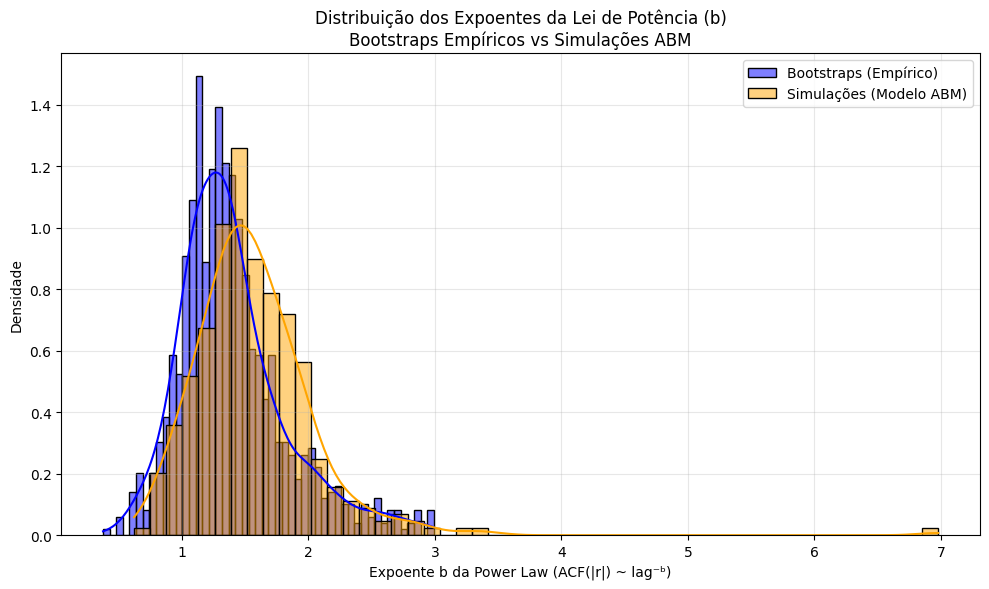

📊 Estatísticas Resumo dos Expoentes b:
Bootstraps → média=1.398, std=0.428
Simulações → média=1.568, std=0.509


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

historico_inicial = []

# ----------------------------------------------------------
# 1. Calcular expoente b para os bootstraps empíricos
# ----------------------------------------------------------
lista_b_boot = []

for i in range(1, 1001):
    serie = bootstraps_500.values[i-1]  # índice Python começa em 0
    serie_com_hist = np.concatenate([historico_inicial, serie])  # adiciona histórico antes
    resultado = msm.calcular_power_law(serie_com_hist, max_lag=40)
    b = resultado["b"]
    if not np.isnan(b):
      if b < 3:
        lista_b_boot.append(b)

print(f"✅ Power law calculado para {len(lista_b_boot)} bootstraps.")

# ----------------------------------------------------------
# 2. Calcular expoente b para as simulações do modelo
# ----------------------------------------------------------
lista_b_sim = []

for k in range(1, 351):  # df_500 simulacoes de 1 a 100
    dados = df_500[df_500["simulacao"] == k]["log_return"].tail(500).dropna()
    if len(dados) > 10:
        resultado = msm.calcular_power_law(dados, max_lag=40)
        b = resultado["b"]
        if not np.isnan(b):
            lista_b_sim.append(b)

print(f"✅ Power law calculado para {len(lista_b_sim)} simulações.")

# ----------------------------------------------------------
# 3. Plotar os histogramas comparativos
# ----------------------------------------------------------
plt.figure(figsize=(10,6))
sns.histplot(lista_b_boot, bins=50, color="blue", kde=True, stat="density", alpha=0.5, label="Bootstraps (Empírico)")
sns.histplot(lista_b_sim, bins=50, color="orange", kde=True, stat="density", alpha=0.5, label="Simulações (Modelo ABM)")

plt.title("Distribuição dos Expoentes da Lei de Potência (b)\nBootstraps Empíricos vs Simulações ABM")
plt.xlabel("Expoente b da Power Law (ACF(|r|) ~ lag⁻ᵇ)")
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. Estatísticas resumo
# ----------------------------------------------------------
print("📊 Estatísticas Resumo dos Expoentes b:")
print(f"Bootstraps → média={np.mean(lista_b_boot):.3f}, std={np.std(lista_b_boot):.3f}")
print(f"Simulações → média={np.mean(lista_b_sim):.3f}, std={np.std(lista_b_sim):.3f}")


In [21]:
def cobertura_power_law(
    df_simulacoes,
    lista_b_boot,
    lista_b_sim,
    num_dias,
    col_sim="simulacao",
    col_retorno="log_return",
    alpha=0.05,
):
    """
    Calcula cobertura do expoente b da Power Law.

    Parâmetros
    ----------
    df_simulacoes : DataFrame com séries simuladas
    lista_b_boot  : lista/array com os b's do bootstrap (referência empírica)
    lista_b_sim   : lista/array com os b's das simulações já calculados (opcional)
    num_dias      : janela de dias a usar de cada simulação
    col_sim       : coluna identificadora da simulação
    col_retorno   : coluna de retornos
    alpha         : nível de significância para o IC (default 5%)
    """

    # IC bootstrap para b
    b_boot = np.array(lista_b_boot)
    b_boot = b_boot[np.isfinite(b_boot)]
    IC_b_inf = np.quantile(b_boot, alpha / 2)
    IC_b_sup = np.quantile(b_boot, 1 - alpha / 2)

    # IC bootstrap para b_sim
    b_sim_arr = np.array(lista_b_sim)
    b_sim_arr = b_sim_arr[np.isfinite(b_sim_arr)]

    sims   = df_simulacoes[col_sim].unique()
    n_sim  = len(sims)
    hits_b = 0
    resultados = []

    for k in sims:
        df_k  = df_simulacoes[df_simulacoes[col_sim] == k].tail(num_dias)
        serie = df_k[col_retorno].values

        resultado = msm.calcular_power_law(serie, max_lag=40)
        b = resultado["b"]

        inside_b = np.isfinite(b) and (IC_b_inf <= b <= IC_b_sup)
        hits_b  += int(inside_b)

        resultados.append({
            "simulacao": k,
            "b":         b,
            "b_inside":  inside_b,
        })

    cobertura_b = 100 * hits_b / n_sim
    df_flags    = pd.DataFrame(resultados)

    print(f"IC bootstrap b: [{IC_b_inf:.4f}, {IC_b_sup:.4f}]")
    print(f"Mediana b bootstrap: {np.median(b_boot):.4f}")
    print(f"Mediana b simulado:  {np.median(b_sim_arr):.4f}")
    print(f"Cobertura b (%): {cobertura_b:.2f}")

    return df_flags, cobertura_b, IC_b_inf, IC_b_sup

In [22]:
df_flags, cob_b, ic_inf, ic_sup = cobertura_power_law(
    df_simulacoes=df_500,
    lista_b_boot=lista_b_boot,       # bootstrap
    lista_b_sim=lista_b_sim,    # simulações
    num_dias=500,
    col_sim="simulacao",
    col_retorno="log_return",
)

IC bootstrap b: [0.7346, 2.5495]
Mediana b bootstrap: 1.3215
Mediana b simulado:  1.4900
Cobertura b (%): 96.86
